# 1. Introdução e objetivo

Este notebook documenta a base técnica dos experimentos do Capítulo 4 da monografia
**"Otimização de Estoques de Segurança em Cadeias de Suprimento: Uso de IA na Predição de Lead Time para Redução de Capital de Giro"**.

O problema estudado é a previsão do tempo total de permanência de uma embarcação no porto. A variável alvo é
`t_total_port_stay_h`, medida em horas, e o instante de previsão é a chegada da embarcação ao porto, representada por
`arrival_port_ts`.

Na prática, a pergunta respondida é: **no momento em que a embarcação chega ao porto, quantas horas ela deve permanecer até a saída?**

Essa previsão é relevante porque o lead time não importa apenas pelo seu valor médio. Sua variabilidade afeta diretamente decisões de planejamento: buffers maiores tendem a aumentar estoque de segurança e capital de giro; buffers menores elevam o risco de falta ou atraso. Por isso, além de modelos pontuais, o notebook também documenta a análise de cauda, a regressão quantílica e a simulação de estoque de segurança.

O notebook reproduz e organiza os resultados oficiais já obtidos na branch `cap4/rebuild-safe-historical-features`. Ele não treina novos algoritmos, não cria novas features e não substitui resultados. As tabelas e figuras são carregadas dos artefatos validados em `results/cap4_rebuild/`.

# 2. Configuração do ambiente

Esta seção concentra imports, caminhos, constantes do experimento e funções auxiliares de apresentação. A modelagem pesada foi executada previamente pela rotina oficial; aqui o foco é documentar e inspecionar os artefatos resultantes.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.3f}".format)

In [2]:
def find_project_root() -> Path:
    # Helper de apresentacao do notebook.`n
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "results" / "cap4_rebuild").exists():
            return candidate
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")


ROOT = find_project_root()
DATA_FILE = ROOT / "data" / "processed" / "eda_base.parquet"
RESULTS = ROOT / "results" / "cap4_rebuild"
FIGURES = RESULTS / "figures"

TARGET = "t_total_port_stay_h"
DATE_COL = "arrival_port_ts"
RANDOM_STATE = 42

RUN_CONFIG = json.loads((RESULTS / "run_config.json").read_text(encoding="utf-8"))
SPLITS = RUN_CONFIG["splits"]

print(f"Raiz do projeto: {ROOT}")
print(f"Dataset: {DATA_FILE.relative_to(ROOT)}")
print(f"Resultados oficiais: {RESULTS.relative_to(ROOT)}")
print(f"Random seed oficial: {RANDOM_STATE}")

Raiz do projeto: G:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction
Dataset: data\processed\eda_base.parquet
Resultados oficiais: results\cap4_rebuild
Random seed oficial: 42


In [3]:
REQUIRED_FILES = [
    DATA_FILE,
    RESULTS / "run_config.json",
    RESULTS / "split_summary.csv",
    RESULTS / "feature_catalog.csv",
    RESULTS / "feature_family_summary.csv",
    RESULTS / "leakage_tests.csv",
    RESULTS / "baseline_reproduction.csv",
    RESULTS / "point_model_comparison_validation.csv",
    RESULTS / "point_model_comparison_final.csv",
    RESULTS / "tail_comparison.csv",
    RESULTS / "quantile_model_comparison.csv",
    RESULTS / "quantile_coverage.csv",
    RESULTS / "uncertainty_global.csv",
    RESULTS / "uncertainty_within_group.csv",
    RESULTS / "safety_stock_simulation.csv",
]

missing = [path for path in REQUIRED_FILES if not path.exists()]
if missing:
    raise FileNotFoundError("Arquivos oficiais ausentes:\n" + "\n".join(str(path) for path in missing))

print("Todos os artefatos oficiais necessários foram encontrados.")

Todos os artefatos oficiais necessários foram encontrados.


In [4]:
def read_result(name: str) -> pd.DataFrame:
    # Helper de apresentacao do notebook.`n
    return pd.read_csv(RESULTS / name)


def metric_table(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    # Helper de apresentacao do notebook.`n
    return df[[column for column in columns if column in df.columns]].copy()


def show_figure(filename: str) -> None:
    # Helper de apresentacao do notebook.`n
    path = FIGURES / filename
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path)))

# 3. Carregamento dos dados

O dataset utilizado é `data/processed/eda_base.parquet`, a base analítica consolidada após leitura, limpeza, integração, construção do target e enriquecimentos previamente validados. Cada linha representa uma escala portuária e combina informações da embarcação, porto, calendário, clima defasado, tipo de operação e histórico temporalmente seguro.

Nesta etapa apenas carregamos a base para inspecionar sua cobertura e a variável alvo. Os resultados de modelagem exibidos nas próximas seções vêm dos artefatos oficiais já gerados.

In [5]:
df = pd.read_parquet(DATA_FILE)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

dataset_summary = pd.DataFrame(
    {
        "item": [
            "registros",
            "variáveis",
            "início do período",
            "fim do período",
            "target",
            "média do target (h)",
            "mediana do target (h)",
        ],
        "valor": [
            f"{len(df):,}",
            f"{df.shape[1]:,}",
            df[DATE_COL].min(),
            df[DATE_COL].max(),
            TARGET,
            df[TARGET].mean(),
            df[TARGET].median(),
        ],
    }
)
dataset_summary

,item,valor
0,registros,"129,625"
1,variáveis,126
2,início do período,2023-01-01 00:08:00
3,fim do período,2025-12-31 23:00:00
4,target,t_total_port_stay_h
5,média do target (h),71.104
6,mediana do target (h),38.417


In [6]:
df.head()

,port_call_id,port,port_name,imo,vessel_id,vessel_name,operation_type,source_port,source_port_name,destination_port,destination_port_name,arrival_port_ts,berthing_ts,unberthing_ts,departure_port_ts,port_display,source_port_display,destination_port_display,has_arrival_port_ts,has_berthing_ts,has_unberthing_ts,has_departure_port_ts,flag_arrival_after_berthing,flag_berthing_after_unberthing,flag_unberthing_after_departure,tmp_wait_for_berthing_h,tmp_operation_h,tmp_post_operation_h,tmp_total_port_stay_h,flag_negative_tmp_wait_for_berthing_h,flag_negative_tmp_operation_h,flag_negative_tmp_post_operation_h,flag_negative_tmp_total_port_stay_h,flag_wait_too_long,flag_operation_too_long,flag_total_too_long,flag_arrival_before_min_date,eligible_for_eda,t_wait_for_berthing_h,t_operation_h,t_post_operation_h,t_total_port_stay_h,t_wait_for_berthing_d,t_operation_d,t_post_operation_d,t_total_port_stay_d,log_t_wait_for_berthing_h,log_t_operation_h,log_t_post_operation_h,log_t_total_port_stay_h,t_wait_for_berthing_h_high,t_wait_for_berthing_h_extreme,t_operation_h_high,t_operation_h_extreme,t_total_port_stay_h_high,t_total_port_stay_h_extreme,arrival_year,arrival_month,arrival_quarter,arrival_weekofyear,...,op_abastecimento_bunker,op_arribada,op_carga,op_descarga,op_desembarque_passageiros,op_embarque_passageiros,op_fundeio,op_fundeio_ship_to_ship,op_navio_estado_com_operacao_comercial,op_navio_estado_marinha_brasil,op_navio_estado_sem_operacao_comercial,op_offshore,op_reparo_manutencao,op_retirada_residuos_com_operacao_comercial,op_retirada_residuos_sem_operacao_comercial,op_solicitacao_certificado,op_tipo_operacao_nao_mapeado,avg_wait_prev_20_calls_port,avg_operation_prev_20_calls_port,std_wait_prev_20_calls_port,arrival_date,arrivals_same_day_port,arrivals_prev_day_port,arrivals_prev_7d_avg_port,port_name_ref,port_display_ref,city,state,region,latitude,longitude,latitude_r,longitude_r,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,rain_sum_prev_1d,precipitation_sum_prev_1d,wind_speed_10m_max_prev_1d,wind_gusts_10m_max_prev_1d,temperature_2m_mean_prev_1d,rain_sum_prev_3d,precipitation_hours_prev_3d,temperature_2m_mean_prev_3d,wind_speed_10m_max_prev_3d,wind_gusts_10m_max_prev_3d,rain_sum_prev_7d,precipitation_hours_prev_7d,temperature_2m_mean_prev_7d,wind_speed_10m_max_prev_7d,wind_gusts_10m_max_prev_7d,has_port_reference,has_weather_data
0,22023,BR052001,TERMINAL FLUVIAL DE JURUTI,9482263,11431725,FORTE DE SÃO FELIPE,Carga e Descarga,BRAMW001,TERMINAL DA ALUMAR - SÃO LUIZ - MA,BRAMW001,TERMINAL DA ALUMAR - SÃO LUIZ - MA,2023-01-04 16:17:00,2023-01-04 16:17:00,2023-01-05 21:34:00,2023-01-05 21:34:00,BR052001 - JURITI - PA,BRAMW001 - TERMINAL DA ALUMAR - SÃO LUIZ - MA,BRAMW001 - TERMINAL DA ALUMAR - SÃO LUIZ - MA,True,True,True,True,False,False,False,0.000,29.283,0.000,29.283,False,False,False,False,False,False,False,False,True,0.000,29.283,0.000,29.283,0.000,1.220,0.000,1.220,0.000,3.411,0.000,3.411,False,False,False,False,False,False,2023,1,1,1,...,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,NaN,2023-01-04,1,NaN,NaN,TERMINAL FLUVIAL DE JURUTI,BR052001 - JURITI - PA,JURITI,PA,NORTE,-2.174,-56.106,-2.174,-56.106,2023-01-04,26.600,30.700,23.100,21.900,21.900,19.000,8.900,22.300,50,22.200,22.200,5.400,22.300,26.000,41.200,45.000,25.900,10.900,24.500,82.200,114.000,25.914,10.900,29.900,1,1
1,5492023,BR052001,TERMINAL FLUVIAL DE JURUTI,9597094,<NA>,TROMBETAS,Carga e Descarga,BRAMW001,TERMINAL DA ALUMAR - SÃO LUIZ - MA,BRAMW001,TERMINAL DA ALUMAR - SÃO LUIZ - MA,2023-01-06 05:18:00,2023-01-06 05:18:00,2023-01-07 11:12:00,2023-01-07 11:12:00,BR052001 - JURITI - PA,BRAMW001 - TERMINAL DA ALUMAR - SÃO LUIZ - MA,BRAMW001 - TERMINAL DA ALUMAR - SÃO LUIZ - MA,True,True,True,True,False,False,False,0.000,29.900,0.000,29.900,False,False,False,False,False,False,Fals

In [7]:
pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_pct": df.isna().mean().mul(100),
    }
).loc[[DATE_COL, TARGET]].round(3)

,dtype,missing_pct
arrival_port_ts,datetime64[ns],0.000
t_total_port_stay_h,float64,0.000


In [8]:
df[[DATE_COL, TARGET]].describe(include="all").T

,count,mean,min,25%,50%,75%,max,std
arrival_port_ts,129625,2024-06-23 04:28:28.487560192,2023-01-01 00:08:00,2023-09-22 10:05:00,2024-06-13 18:30:00,2025-03-24 12:15:00,2025-12-31 23:00:00,NaN
t_total_port_stay_h,"129,625.000",71.104,0.017,18.900,38.417,80.833,"1,280.083",97.116


# 4. Preparação dos dados para modelagem

A preparação para modelagem foi guiada por uma regra central: uma variável só pode entrar no modelo se estiver disponível, ou se puder ser calculada apenas com informação já conhecida, no instante da chegada da embarcação.

O objetivo desta seção é explicar como o experimento preserva a ordem temporal e como as famílias históricas foram organizadas para reduzir o risco de vazamento temporal.

## 4.1 Divisão temporal

Não foi utilizado split aleatório porque o problema simula uma aplicação preditiva ao longo do tempo. Se observações futuras fossem misturadas no treino, o modelo poderia aprender padrões que não estariam disponíveis no momento real da previsão.

Por isso, os conjuntos foram definidos por intervalos semiabertos em `arrival_port_ts`:

- **Train:** de `2023-01-01` até antes de `2024-07-01`;
- **Validation:** de `2024-07-01` até antes de `2025-01-01`;
- **Calibration:** de `2025-01-01` até antes de `2025-07-01`;
- **Final Test:** de `2025-07-01` até antes de `2026-01-01`.

O modelo vencedor foi escolhido usando `validation`. O `final_test` permaneceu reservado para avaliação final, sem uso na escolha de modelo, feature set ou hiperparâmetros.

In [9]:
split_summary = read_result("split_summary.csv")
split_summary

,split,n_rows,period_start,period_end,target_mean_h,target_median_h,target_q90_h,target_q95_h
0,train,66909,2023-01-01 00:08:00,2024-06-30 23:30:00,70.020,36.900,161.417,254.133
1,validation,20362,2024-07-01 00:00:00,2024-12-31 22:40:00,77.414,42.508,180.475,278.027
2,calibration,21352,2025-01-01 00:05:00,2025-06-30 23:40:00,69.176,37.833,157.083,237.279
3,final_test,21002,2025-07-01 00:00:00,2025-12-31 23:00:00,70.399,39.717,159.163,241.988


In [10]:
split_boundaries = pd.DataFrame(
    [
        ["train", SPLITS["train_start"], SPLITS["validation_start"]],
        ["validation", SPLITS["validation_start"], SPLITS["calibration_start"]],
        ["calibration", SPLITS["calibration_start"], SPLITS["final_test_start"]],
        ["final_test", SPLITS["final_test_start"], SPLITS["final_test_end"]],
    ],
    columns=["split", "início inclusivo", "fim exclusivo"],
)
split_boundaries

,split,início inclusivo,fim exclusivo
0,train,2023-01-01,2024-07-01
1,validation,2024-07-01,2025-01-01
2,calibration,2025-01-01,2025-07-01
3,final_test,2025-07-01,2026-01-01


## 4.2 Construção das features temporais seguras

### Revisão das variáveis históricas e prevenção de vazamento temporal

Durante a EDA foram encontrados sinais associados a congestionamento, memória operacional do porto, histórico de embarcações, rotas, origem/destino e desempenho operacional anterior. Esses sinais são relevantes porque a permanência portuária tende a depender do estado operacional acumulado, e não apenas das características estáticas da escala.

Antes da modelagem final, as variáveis históricas foram reconstruídas para respeitar a disponibilidade temporal da informação. Algumas versões exploratórias poderiam usar dados ainda indisponíveis no instante da chegada. No experimento oficial, a regra adotada foi:

**Para uma escala no dia D, somente informações disponíveis até 23:59:59 de D-1 podem ser utilizadas.**

Isso significa que a escala atual não contribui para suas próprias features, chegadas posteriores no mesmo dia não são contadas e estatísticas históricas só usam eventos já conhecidos. A construção foi validada por testes de leakage salvos no artefato `leakage_tests.csv`.

In [11]:
leakage_tests = read_result("leakage_tests.csv")
leakage_tests

,test,passed,detail
0,evento_do_proprio_dia_nao_altera_features_d_me...,True,Evento em D nao afetou fluxo com cutoff D-1.
1,evento_futuro_nao_altera_features_passadas,True,Evento futuro em fevereiro nao afetou corte de...
2,espera_so_disponivel_depois_da_atracacao,True,"counts=0.0,1.0"
3,operacao_so_disponivel_depois_da_desatracacao,True,"counts=0.0,1.0"
4,permanencia_so_disponivel_depois_da_saida,True,"counts=0.0,1.0"
5,dias_calendario_sem_eventos_existem_com_zero,True,Jan 4 arrivals_prev_1d=0.0
6,target_da_propria_observacao_nao_entra_na_feature,True,known count=0.0
7,rolling_nao_usa_linhas_futuras,True,D-1 de 2024-01-03 e 2024-01-02: 0.0
8,merge_exclui_eventos_conhecidos_no_futuro,True,searchsorted side='right' aplica cutoff_ts.
9,imputacao_ajustada_apenas_no_treino,True,"statistics before=2.0, after=2.0"


In [12]:
pd.DataFrame(
    {
        "checagem": ["Todos os testes de leakage aprovados?"],
        "resultado": [bool(leakage_tests["passed"].all())],
    }
)

,checagem,resultado
0,Todos os testes de leakage aprovados?,True


## 4.3 Catálogo das novas famílias de variáveis

As famílias abaixo organizam as variáveis históricas seguras usadas no conjunto `ENRICHED_SAFE_HISTORY`. Elas entram no experimento como parte da preparação dos dados desde o início da modelagem final.

| Família | Descrição | Exemplos |
|---|---|---|
| Fluxo operacional histórico | Resume entradas, saídas e saldo recente do porto, ajudando a capturar pressão operacional acumulada. | chegadas recentes; saídas recentes; balanço de fluxo |
| Estado operacional reconstruído | Aproxima o estado do porto conhecido até D-1, representando filas e ocupação operacional. | navios aguardando; navios presentes; backlog operacional |
| Histórico do porto | Resume desempenho histórico do porto em espera, operação e permanência total. | permanência média; quantis históricos; desempenho anterior |
| Histórico navio × porto | Captura recorrência de uma embarcação específica em um porto específico. | contagem anterior; média anterior; mediana anterior |
| Histórico de rota | Resume comportamento histórico de pares origem-destino ou trajetórias operacionais equivalentes. | mediana da rota; média da rota; quantidade conhecida |
| Histórico de origem/destino | Captura padrões associados aos portos de origem e destino separadamente. | histórico da origem; histórico do destino; quantis anteriores |
| Mix operacional recente | Mede a composição recente dos tipos de operação do porto, pois diferentes operações podem gerar cargas operacionais distintas. | participação recente de carga; descarga; fundeio; offshore; reparo |

In [13]:
feature_catalog = read_result("feature_catalog.csv")
new_or_rebuilt = feature_catalog[
    feature_catalog["foi_reconstruida_devido_a_leakage"].astype(bool)
    | feature_catalog["familia"].str.contains("HISTORICO|FLUXO|ESTADO|MIX", case=False, na=False)
].copy()
new_or_rebuilt.head(20)

,feature,familia,descricao_linguagem_negocio,disponibilidade_temporal,regra_de_construcao,existia_originalmente_na_eda,foi_reconstruida_devido_a_leakage,entra_na_modelagem_final
46,arrivals_prev_1d,FLUXO_PORTUARIO_HISTORICO,Mede volume recente de entradas e saidas no po...,Conhecida ate 23:59:59 de D-1 por reconstrucao...,Construida com calendario porto-dia completo e...,False,True,True
47,arrivals_prev_3d,FLUXO_PORTUARIO_HISTORICO,Mede volume recente de entradas e saidas no po...,Conhecida ate 23:59:59 de D-1 por reconstrucao...,Construida com calendario porto-dia completo e...,False,True,True
48,arrivals_prev_7d,FLUXO_PORTUARIO_HISTORICO,Mede volume recente de entradas e saidas no po...,Conhecida ate 23:59:59 de D-1 por reconstrucao...,Construida com calendario porto-dia completo e...,False,True,True
49,arrivals_avg_prev_3d,FLUXO_PORTUARIO_HISTORICO,Mede volume recente de entradas e saidas no po...,Conhecida ate 23:59:59 de D-1 por reconstrucao...,Construida com calendario porto-dia completo e...,False,True,True
50,arrivals_max_prev_3d,FLUXO_PORTUARIO_HISTORICO,Mede volume recente de entradas e saidas no po...,Conhecida ate 23:59:59 de D-1 por reconstrucao...,Construida com calendario porto-dia completo e...,False,True,True
51,arrivals_avg_prev_7d,FLUXO_PORTUARIO_HISTORICO,Mede volume recente de entradas e saidas no po...,Conhecida ate 23:59:59 de D-1 por reconstrucao...,Construida com calendario porto-dia completo e...,False,True,True
52,arrivals_max_prev_7d,FLUXO_PORTUARIO_HISTORICO,Mede volume recente de entradas e saidas no po...,Conhecida ate 23:59:59 de D-1 por reconstrucao...,Construida com calendario porto-dia completo e...,False,True,True
53,departures_prev_1d,FLUXO_PORTUARIO_HISTORICO,Mede volume recente de entradas e saidas no po...,Conhecida ate 23:59:59 de D-1 por reconstrucao...,Construida com calendario porto-dia completo e...,False,True,True
54,departures_prev_3d,FLUXO_PORTUARIO_HISTORICO,Mede volume recente de entradas e saidas no po...,Conhecida ate 23:59:59 de D-1 por reconstrucao...,Construida com calendario porto-dia completo e...,False,True,True
55,departures_prev_7d,FLUXO_PORTUARIO_HISTORICO,Mede volume recente de entradas e saidas no po...,Conhecida ate 23:59:59 de D-1 por reconstrucao...,Construida com calendario porto-dia completo e...,False,True,True


In [14]:
feature_family_summary = read_result("feature_family_summary.csv")
feature_family_summary

,family,feature_origin,n_features,total_importance_h,mean_importance_h,max_importance_h
0,ESTRUTURAL_GEOGRAFICA,original,3,5.319,1.773,5.308
1,OPERACIONAL_DA_ESCALA,original,17,3.947,0.232,1.547
2,HISTORICO_DE_ROTA,new,4,2.879,0.720,2.365
3,HISTORICO_DE_ORIGEM,new,4,1.315,0.329,0.826
4,ESTADO_OPERACIONAL_RECONSTRUIDO_D_1,new,5,0.858,0.172,0.779
5,HISTORICO_EMBARCACAO_PORTO,new,4,0.813,0.203,0.419
6,HISTORICO_DE_DESTINO,new,4,0.510,0.127,0.222
7,HISTORICO_DA_EMBARCACAO,new,8,0.389,0.049,0.242
8,DESEMPENHO_HISTORICO_CONHECIDO_DO_PORTO,new,18,0.237,0.013,0.113
9,FLUXO_PORTUARIO_HISTORICO,new,17,0.105,0.006,0.053


# 5. Baseline histórico

O baseline histórico existe para representar uma política simples e interpretável: prever a permanência a partir de estatísticas históricas, sem aprendizado supervisionado complexo. Ele é importante porque qualquer modelo de Machine Learning precisa superar uma referência operacional plausível.

No experimento foram avaliados baselines por mediana global, mediana por porto e mediana hierárquica porto × tipo de operação com fallback. As métricas abaixo são MAE, RMSE, MedAE e RMSLE, além de métricas de cauda.

In [15]:
baseline = read_result("baseline_reproduction.csv")
metric_table(
    baseline,
    ["model", "feature_config", "dataset", "mae", "rmse", "medae", "rmsle", "mae_q90", "mae_q95"],
)

,model,feature_config,dataset,mae,rmse,medae,rmsle,mae_q90,mae_q95
0,baseline_global_median,ORIGINAL,validation,56.363,112.085,23.933,1.100,270.244,376.893
1,baseline_median_by_port,ORIGINAL,validation,52.102,108.128,20.667,0.982,256.895,363.559
2,baseline_hierarchical_port_operation,ORIGINAL,validation,47.864,100.997,19.283,0.895,233.397,338.958
3,ridge_original,ORIGINAL,validation,53.120,130.497,20.332,0.939,244.579,347.723
4,random_forest_original,ORIGINAL,validation,47.588,99.295,19.325,0.876,229.470,331.711
5,gradient_boosting_original,ORIGINAL,validation,47.607,99.513,18.992,0.877,229.146,330.782
6,hist_gradient_boosting_original,ORIGINAL,validation,47.304,98.983,19.034,0.869,227.581,329.940


# 6. Modelos de Machine Learning

Cada modelo é apresentado com o mesmo padrão: intuição do algoritmo, configuração usada, resultado com features originais, resultado com features históricas seguras e interpretação. Os resultados desta seção são os resultados oficiais de validação; nenhum modelo é treinado novamente neste notebook.

In [16]:
validation_results = read_result("point_model_comparison_validation.csv")
model_columns = [
    "model", "feature_config", "dataset", "mae", "rmse", "medae", "rmsle",
    "mae_q90", "mae_q95", "underprediction_rate_q90", "underprediction_rate_q95",
]
validation_results = metric_table(validation_results, model_columns)
validation_results

,model,feature_config,dataset,mae,rmse,medae,rmsle,mae_q90,mae_q95,underprediction_rate_q90,underprediction_rate_q95
0,baseline_hierarchical,ORIGINAL,validation,47.864,100.997,19.283,0.895,233.397,338.958,0.997,1.000
1,baseline_hierarchical,ORIGINAL,calibration,41.557,88.767,16.417,0.857,224.828,337.849,0.995,1.000
2,Ridge,ORIGINAL,validation,53.120,130.497,20.332,0.939,244.579,347.723,0.995,0.997
3,Ridge,ORIGINAL,calibration,47.011,121.917,18.589,0.920,235.694,346.803,0.995,0.999
4,Ridge,ENRICHED_SAFE_HISTORY,validation,48.080,100.725,19.304,0.870,222.650,321.805,0.984,0.994
5,Ridge,ENRICHED_SAFE_HISTORY,calibration,43.451,167.043,17.696,0.861,218.552,326.517,0.982,0.990
6,Random Forest,ORIGINAL,validation,47.588,99.295,19.325,0.876,229.470,331.711,0.999,1.000
7,Random Forest,ORIGINAL,calibration,42.040,87.978,17.551,0.853,221.959,332.938,1.000,1.000
8,Random Forest,ENRICHED_SAFE_HISTORY,validation,45.271,95.932,18.551,0.820,219.422,319.064,0.996,1.000
9,Random Forest,ENRICHED_SAFE_HISTORY,calibration,39.804,86.238,16.101,0.799,217.653,330.212,0.996,1.000


## Ridge Regression

O Ridge é um modelo linear regularizado. Ele serve como referência paramétrica: se o ganho das features históricas aparece mesmo em um modelo simples, isso indica que parte do sinal é sistemático e não depende apenas de modelos de árvore.

Configuração utilizada: regressão Ridge com target transformado em `log1p`, seleção de `alpha` na validação e preprocessamento compatível com variáveis numéricas e categóricas.

In [17]:
validation_results.query("model == 'Ridge'")

,model,feature_config,dataset,mae,rmse,medae,rmsle,mae_q90,mae_q95,underprediction_rate_q90,underprediction_rate_q95
2,Ridge,ORIGINAL,validation,53.120,130.497,20.332,0.939,244.579,347.723,0.995,0.997
3,Ridge,ORIGINAL,calibration,47.011,121.917,18.589,0.920,235.694,346.803,0.995,0.999
4,Ridge,ENRICHED_SAFE_HISTORY,validation,48.080,100.725,19.304,0.870,222.650,321.805,0.984,0.994
5,Ridge,ENRICHED_SAFE_HISTORY,calibration,43.451,167.043,17.696,0.861,218.552,326.517,0.982,0.990


Interpretação: a comparação entre `ORIGINAL` e `ENRICHED_SAFE_HISTORY` mostra o efeito das features históricas seguras sobre uma estrutura linear. O resultado ajuda a separar ganho de informação de ganho puramente algorítmico.

## Random Forest

O Random Forest combina várias árvores de decisão treinadas com aleatoriedade controlada. Ele é útil para capturar relações não lineares e interações entre porto, operação, calendário e histórico.

Configuração utilizada: `RandomForestRegressor` com `random_state=42`, `n_estimators=250`, `min_samples_leaf=50`, `max_features=1.0` e predição no espaço original após treino em `log1p(target)`.

In [18]:
validation_results.query("model == 'Random Forest'")

,model,feature_config,dataset,mae,rmse,medae,rmsle,mae_q90,mae_q95,underprediction_rate_q90,underprediction_rate_q95
6,Random Forest,ORIGINAL,validation,47.588,99.295,19.325,0.876,229.470,331.711,0.999,1.000
7,Random Forest,ORIGINAL,calibration,42.040,87.978,17.551,0.853,221.959,332.938,1.000,1.000
8,Random Forest,ENRICHED_SAFE_HISTORY,validation,45.271,95.932,18.551,0.820,219.422,319.064,0.996,1.000
9,Random Forest,ENRICHED_SAFE_HISTORY,calibration,39.804,86.238,16.101,0.799,217.653,330.212,0.996,1.000


Interpretação: o ganho com `ENRICHED_SAFE_HISTORY` indica que a memória operacional e os históricos por grupo adicionam informação preditiva além das variáveis estruturais, calendário, clima defasado e flags de operação.

## Gradient Boosting

O Gradient Boosting ajusta árvores sequenciais, cada uma tentando corrigir erros residuais das anteriores. No experimento, ele foi usado como modelo de boosting clássico para comparar desempenho contra Random Forest e HistGradientBoosting.

Configuração utilizada: `GradientBoostingRegressor` com perda Huber, `n_estimators=300`, `learning_rate=0.10`, `max_depth=7`, `min_samples_leaf=20` e `random_state=42`.

In [19]:
validation_results.query("model == 'Gradient Boosting'")

,model,feature_config,dataset,mae,rmse,medae,rmsle,mae_q90,mae_q95,underprediction_rate_q90,underprediction_rate_q95
10,Gradient Boosting,ORIGINAL,validation,47.607,99.513,18.992,0.877,229.146,330.782,0.993,0.997
11,Gradient Boosting,ORIGINAL,calibration,42.233,88.464,17.352,0.859,222.910,333.950,0.995,1.000
12,Gradient Boosting,ENRICHED_SAFE_HISTORY,validation,45.186,94.418,18.454,0.819,210.639,308.522,0.981,0.992
13,Gradient Boosting,ENRICHED_SAFE_HISTORY,calibration,40.133,84.274,16.809,0.803,204.780,311.775,0.984,0.998


Interpretação: a comparação mostra se o enriquecimento histórico melhora um modelo capaz de capturar não linearidades e interações. A leitura principal deve ser feita em validação, preservando o teste final.

## HistGradientBoosting

O HistGradientBoosting é uma implementação eficiente de gradient boosting baseada em histogramas. Ele foi o modelo pontual congelado para a avaliação final.

Configuração utilizada: `HistGradientBoostingRegressor` com `loss='squared_error'`, `learning_rate=0.10`, `max_iter=300`, `max_leaf_nodes=15`, `min_samples_leaf=20`, `l2_regularization=1.0`, tratamento categórico a partir de dtype e `random_state=42`.

In [20]:
validation_results.query("model == 'HistGradientBoosting'")

,model,feature_config,dataset,mae,rmse,medae,rmsle,mae_q90,mae_q95,underprediction_rate_q90,underprediction_rate_q95
14,HistGradientBoosting,ORIGINAL,validation,47.304,98.983,19.034,0.869,227.581,329.940,0.994,0.999
15,HistGradientBoosting,ORIGINAL,calibration,41.830,88.007,16.922,0.848,221.565,333.095,0.996,0.999
16,HistGradientBoosting,ENRICHED_SAFE_HISTORY,validation,44.535,94.560,17.821,0.803,213.864,313.598,0.989,0.999
17,HistGradientBoosting,ENRICHED_SAFE_HISTORY,calibration,39.449,84.413,16.326,0.787,209.764,319.601,0.990,1.000


Interpretação: em validação, o HistGradientBoosting com features históricas seguras apresentou o menor MAE e foi selecionado antes de consultar o `final_test`. Essa escolha mantém o teste final como avaliação honesta de generalização temporal.

# 7. Comparação dos modelos

A tabela consolidada abaixo separa validação e teste final. A seleção do modelo vencedor foi feita **sem usar o final_test**: o critério oficial foi menor MAE em `validation`, com desempate por RMSE e MAE na cauda Q90. A calibração foi usada como verificação secundária.

In [21]:
final_results = read_result("point_model_comparison_final.csv")

comparison_validation = metric_table(
    read_result("point_model_comparison_validation.csv").query("dataset == 'validation'"),
    ["model", "feature_config", "dataset", "mae", "rmse", "medae", "rmsle", "mae_q90", "mae_q95"],
)
comparison_final = metric_table(
    final_results,
    ["model", "feature_config", "dataset", "mae", "rmse", "medae", "rmsle", "mae_q90", "mae_q95"],
)

pd.concat([comparison_validation, comparison_final], ignore_index=True)

,model,feature_config,dataset,mae,rmse,medae,rmsle,mae_q90,mae_q95
0,baseline_hierarchical,ORIGINAL,validation,47.864,100.997,19.283,0.895,233.397,338.958
1,Ridge,ORIGINAL,validation,53.120,130.497,20.332,0.939,244.579,347.723
2,Ridge,ENRICHED_SAFE_HISTORY,validation,48.080,100.725,19.304,0.870,222.650,321.805
3,Random Forest,ORIGINAL,validation,47.588,99.295,19.325,0.876,229.470,331.711
4,Random Forest,ENRICHED_SAFE_HISTORY,validation,45.271,95.932,18.551,0.820,219.422,319.064
5,Gradient Boosting,ORIGINAL,validation,47.607,99.513,18.992,0.877,229.146,330.782
6,Gradient Boosting,ENRICHED_SAFE_HISTORY,validation,45.186,94.418,18.454,0.819,210.639,308.522
7,HistGradientBoosting,ORIGINAL,validation,47.304,98.983,19.034,0.869,227.581,329.940
8,HistGradientBoosting,ENRICHED_SAFE_HISTORY,validation,44.535,94.560,17.821,0.803,213.864,313.598
9,HistGradientBoosting,ORIGINAL,final_test,41.670,83.760,17.783,0.834,211.307,308.003


In [22]:
winner = RUN_CONFIG["winner"]
pd.DataFrame(
    {
        "campo": ["modelo", "feature_config", "dataset de seleção", "critério", "MAE validation"],
        "valor": [
            winner["model"],
            winner["feature_config"],
            winner["dataset"],
            winner["selection_criterion"],
            winner["mae"],
        ],
    }
)

,campo,valor
0,modelo,HistGradientBoosting
1,feature_config,ENRICHED_SAFE_HISTORY
2,dataset de seleção,validation
3,critério,Menor MAE em validation; desempate por RMSE e ...
4,MAE validation,44.535


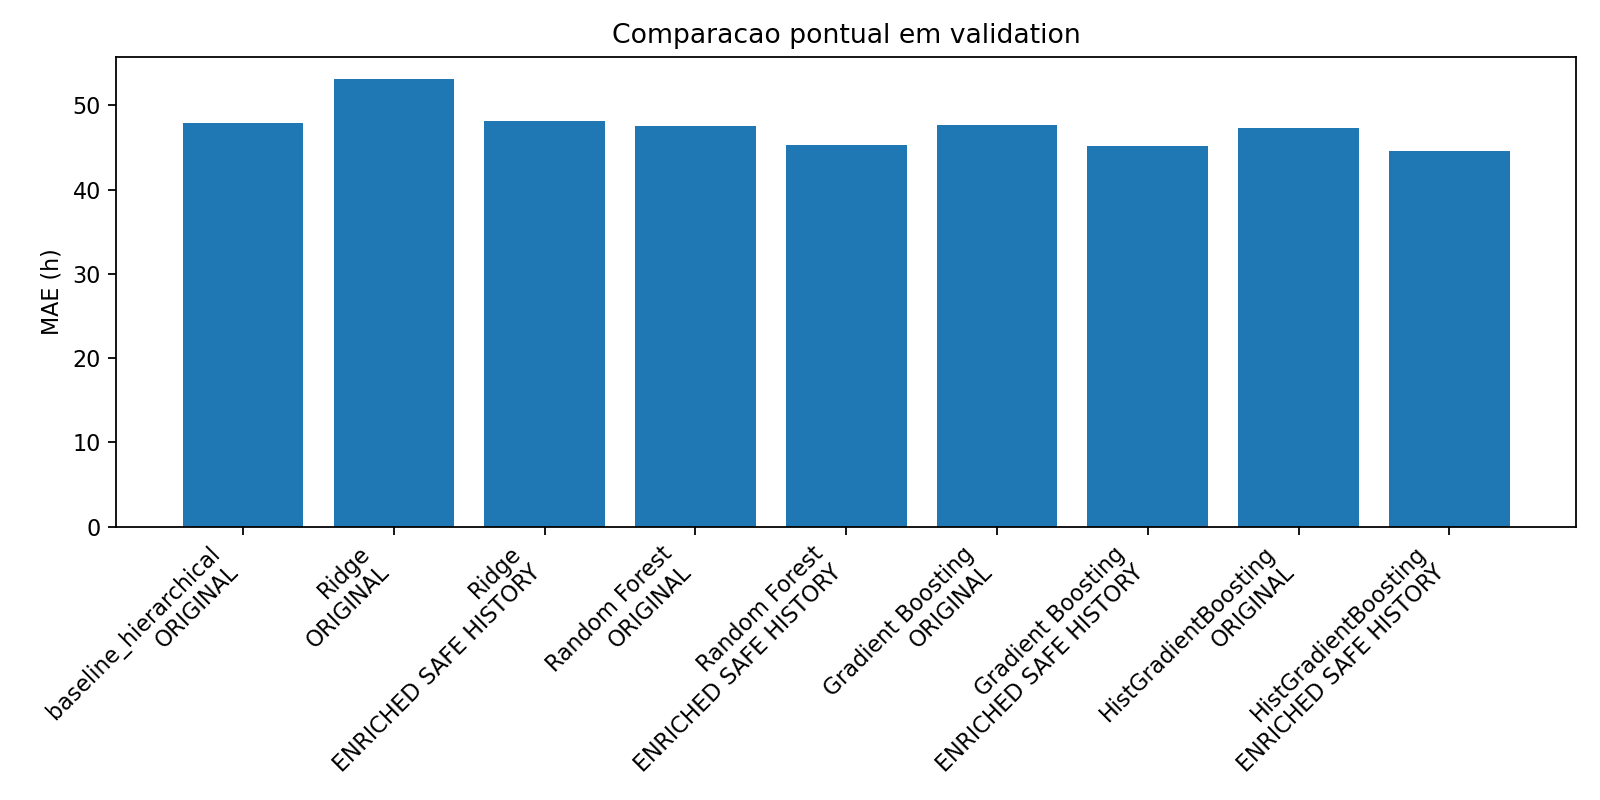

In [23]:
show_figure("point_model_evolution.png")

# 8. Avaliação da cauda da distribuição

A cauda é importante porque atrasos extremos são justamente os eventos que mais pressionam decisões de estoque de segurança. Um modelo pode reduzir o erro médio e ainda assim continuar subestimando permanências muito longas.

Nesta seção são avaliados Q90, Q95, bias e taxa de underprediction. A leitura principal é: os modelos pontuais melhoram a previsão média, mas eventos extremos continuam difíceis.

In [24]:
tail = read_result("tail_comparison.csv")
tail

,model,feature_config,dataset,mae_q90,mae_q95,bias_q90,bias_q95,underprediction_rate_q90,underprediction_rate_q95
0,HistGradientBoosting,ORIGINAL,final_test,211.307,308.003,-211.112,-308.003,0.998,1.000
1,HistGradientBoosting,ENRICHED_SAFE_HISTORY,final_test,198.020,292.101,-197.483,-292.101,0.991,1.000


In [25]:
tail.assign(
    ganho_mae_q90_h=tail["mae_q90"].iloc[0] - tail["mae_q90"],
    ganho_mae_q95_h=tail["mae_q95"].iloc[0] - tail["mae_q95"],
)

,model,feature_config,dataset,mae_q90,mae_q95,bias_q90,bias_q95,underprediction_rate_q90,underprediction_rate_q95,ganho_mae_q90_h,ganho_mae_q95_h
0,HistGradientBoosting,ORIGINAL,final_test,211.307,308.003,-211.112,-308.003,0.998,1.000,0.000,0.000
1,HistGradientBoosting,ENRICHED_SAFE_HISTORY,final_test,198.020,292.101,-197.483,-292.101,0.991,1.000,13.287,15.901


A predominância de bias negativo e underprediction elevado na cauda indica que previsões pontuais tendem a ficar abaixo da permanência realizada nos casos extremos. Isso motiva a passagem para uma abordagem probabilística, capaz de representar níveis de risco por quantis.

# 9. Modelo probabilístico / regressão quantílica

A previsão pontual estima um valor central esperado para cada escala. A regressão quantílica estima pontos da distribuição condicional: P50 representa uma mediana prevista, P90 e P95 representam limites superiores associados a maior proteção contra atrasos.

No experimento, os quantis P50, P90 e P95 foram estimados por Gradient Boosting quantílico após o fluxo pontual ter sido congelado. As métricas incluem pinball loss, cobertura empírica e largura dos intervalos.

In [26]:
quantile_comparison = read_result("quantile_model_comparison.csv")
quantile_comparison

,model,feature_config,dataset,quantile_crossing_rate_raw,mean_width_p90_p50_h,mean_width_p95_p50_h,pinball_p50,pinball_p90,pinball_p95
0,hgb_quantile_log,ORIGINAL,calibration,0.023,96.209,153.714,20.635,17.203,12.211
1,hgb_quantile_log,ORIGINAL,final_test,0.023,103.611,164.371,20.971,16.696,11.747
2,hgb_quantile_log,ENRICHED_SAFE_HISTORY,calibration,0.035,84.648,129.381,19.373,15.436,10.943
3,hgb_quantile_log,ENRICHED_SAFE_HISTORY,final_test,0.035,87.390,134.785,19.345,15.169,10.702
4,baseline_quantile_hierarchical,ORIGINAL,calibration,0.000,104.088,165.678,20.640,17.251,12.143
5,baseline_quantile_hierarchical,ORIGINAL,final_test,0.000,103.537,164.288,20.962,16.601,11.599


In [27]:
quantile_coverage = read_result("quantile_coverage.csv")
quantile_coverage

,model,feature_config,dataset,quantile,target_coverage,empirical_coverage,pinball_loss
0,hgb_quantile_log,ORIGINAL,calibration,p50,0.500,0.496,20.635
1,hgb_quantile_log,ORIGINAL,calibration,p90,0.900,0.894,17.203
2,hgb_quantile_log,ORIGINAL,calibration,p95,0.950,0.943,12.211
3,hgb_quantile_log,ORIGINAL,final_test,p50,0.500,0.494,20.971
4,hgb_quantile_log,ORIGINAL,final_test,p90,0.900,0.900,16.696
5,hgb_quantile_log,ORIGINAL,final_test,p95,0.950,0.950,11.747
6,hgb_quantile_log,ENRICHED_SAFE_HISTORY,calibration,p50,0.500,0.530,19.373
7,hgb_quantile_log,ENRICHED_SAFE_HISTORY,calibration,p90,0.900,0.900,15.436
8,hgb_quantile_log,ENRICHED_SAFE_HISTORY,calibration,p95,0.950,0.943,10.943
9,hgb_quantile_log,ENRICHED_SAFE_HISTORY,final_test,p50,0.500,0.510,19.345


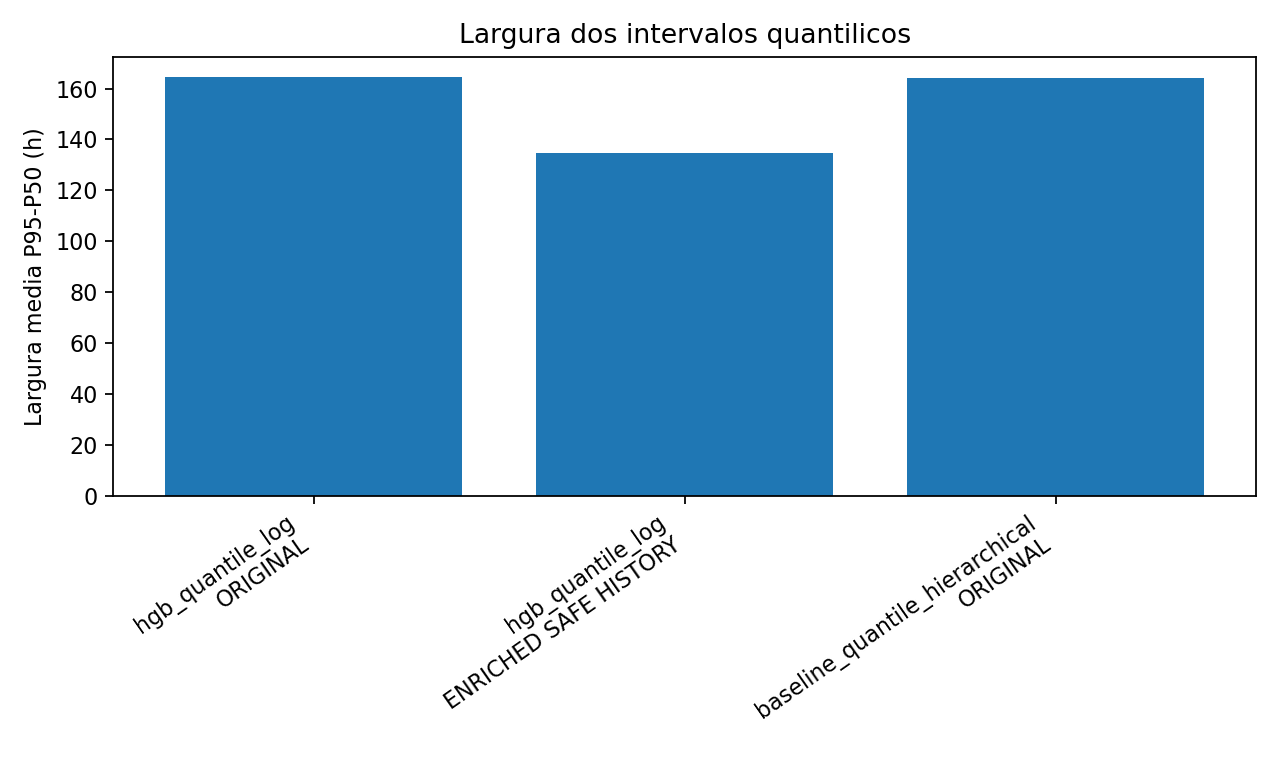

In [28]:
show_figure("quantile_width_p95_p50.png")

Os quantis representam risco porque permitem escolher uma política mais conservadora quando o custo de atraso é alto. P90 e P95 não devem ser lidos como "melhores previsões pontuais", mas como buffers estatísticos condicionados ao contexto observado.

# 10. Análise do intervalo P95-P50

A largura `P95 - P50` foi analisada como uma medida de incerteza do próprio modelo. A hipótese é que intervalos mais largos indiquem casos em que o modelo percebe maior dispersão possível de permanência.

A análise abaixo mostra associação global com erro absoluto e permanência realizada, além de uma leitura por grupos porto × operação. A conclusão deve ser moderada: a largura ajuda a ordenar risco em parte dos casos, mas não elimina a dificuldade de prever extremos.

In [29]:
uncertainty_global = read_result("uncertainty_global.csv")
uncertainty_global

,measure,spearman_abs_error,spearman_actual_stay,mean_width_h,median_width_h,risk_quintile,n,mean_abs_error_h,mean_actual_h,extreme_rate,mean_width_p95_p50_h
0,width_p90_p50_h,0.559,0.502,87.390,69.983,NaN,NaN,NaN,NaN,NaN,NaN
1,width_p95_p50_h,0.552,0.495,134.785,116.746,NaN,NaN,NaN,NaN,NaN,NaN
2,risk_quintile,NaN,NaN,NaN,NaN,Q1,"4,201.000",8.744,25.431,0.005,22.683
3,risk_quintile,NaN,NaN,NaN,NaN,Q2,"4,200.000",20.693,46.091,0.025,67.227
4,risk_quintile,NaN,NaN,NaN,NaN,Q3,"4,200.000",33.108,62.432,0.067,117.808
5,risk_quintile,NaN,NaN,NaN,NaN,Q4,"4,200.000",48.497,83.222,0.124,178.592
6,risk_quintile,NaN,NaN,NaN,NaN,Q5,"4,201.000",82.407,134.816,0.279,287.607


In [30]:
uncertainty_within = read_result("uncertainty_within_group.csv")
uncertainty_within.head(20)

,port,operation_type,n,spearman_width_abs_error,spearman_width_actual,hist_actual_std_h,mean_width_p95_p50_h,can_individualize_risk
0,BR052001,Carga,73,0.052,0.025,35.580,20.985,False
1,BR302002,Descarga,30,-0.030,0.117,26.468,36.225,False
2,BR400001,Carga,113,-0.049,0.036,64.264,130.927,False
3,BR400001,Descarga,80,0.135,0.122,23.584,64.707,False
4,BR997001,Carga,69,0.303,0.309,20.727,14.603,True
5,BRADR,Desembarque/Embarque de Passageiros,56,-0.076,0.006,83.781,173.778,False
6,BRADR003,Carga e Descarga,188,0.266,0.367,84.676,174.578,True
7,BRADR003,Descarga,36,0.088,0.274,117.925,210.153,False
8,BRAMW001,Carga,46,0.303,0.082,18.178,105.690,True
9,BRAMW001,Descarga,120,-0.046,0.183,27.387,51.614,False


In [31]:
pd.DataFrame(
    {
        "métrica": [
            "grupos porto × operação com n >= 30",
            "mediana da correlação largura-erro",
            "grupos com individualização de risco",
        ],
        "valor": [
            len(uncertainty_within),
            uncertainty_within["spearman_width_abs_error"].median(),
            int(uncertainty_within["can_individualize_risk"].sum()),
        ],
    }
)

,métrica,valor
0,grupos porto × operação com n >= 30,103.000
1,mediana da correlação largura-erro,0.178
2,grupos com individualização de risco,48.000


# 11. Simulação de estoque de segurança

A base não contém demanda real por item, custo unitário real, estoque real ou lead time logístico completo. Portanto, a conexão com capital de giro é tratada como **simulação de cenário**, não como economia real observada de uma empresa específica.

A cadeia conceitual é:

**lead time previsto → variabilidade → estoque de segurança → capital de giro**

Foram comparados quatro tipos de política:

- **Cenário 1: Política histórica** (`A_static_segment_port_operation`);
- **Cenário 2: Modelo pontual** (`B_dynamic_original_point` e `C_dynamic_enriched_point`);
- **Cenário 3: P90** (`D_dynamic_quantile_p90`);
- **Cenário 4: P95** (`D_dynamic_quantile_p95`).

As premissas e resultados são os mesmos já salvos nos artefatos oficiais.

In [32]:
safety_stock = read_result("safety_stock_simulation.csv")
safety_stock.query("scenario == 'base'")

,scenario,demand_mean_units_d,demand_std_units_d,service_z,unit_value_brl,policy,mean_policy_lead_time_d,mean_safety_stock_units,proxy_working_capital_brl,protection_rate,mean_buffer_excess_d,underbuffer_rate
0,base,100.000,25.000,1.650,50.000,A_static_segment_port_operation,5.863,725.317,"36,265.833",0.896,2.929,0.104
1,base,100.000,25.000,1.650,50.000,B_dynamic_original_point,2.134,239.021,"11,951.073",0.529,-0.799,0.471
2,base,100.000,25.000,1.650,50.000,C_dynamic_enriched_point,2.193,262.325,"13,116.245",0.523,-0.740,0.477
3,base,100.000,25.000,1.650,50.000,D_dynamic_quantile_p90,5.787,727.292,"36,364.593",0.895,2.853,0.105
4,base,100.000,25.000,1.650,50.000,D_dynamic_quantile_p95,7.761,887.057,"44,352.826",0.944,4.828,0.056


In [33]:
metric_table(
    safety_stock.query("scenario == 'base'"),
    [
        "policy",
        "mean_policy_lead_time_d",
        "mean_safety_stock_units",
        "proxy_working_capital_brl",
        "protection_rate",
        "underbuffer_rate",
    ],
)

,policy,mean_policy_lead_time_d,mean_safety_stock_units,proxy_working_capital_brl,protection_rate,underbuffer_rate
0,A_static_segment_port_operation,5.863,725.317,"36,265.833",0.896,0.104
1,B_dynamic_original_point,2.134,239.021,"11,951.073",0.529,0.471
2,C_dynamic_enriched_point,2.193,262.325,"13,116.245",0.523,0.477
3,D_dynamic_quantile_p90,5.787,727.292,"36,364.593",0.895,0.105
4,D_dynamic_quantile_p95,7.761,887.057,"44,352.826",0.944,0.056


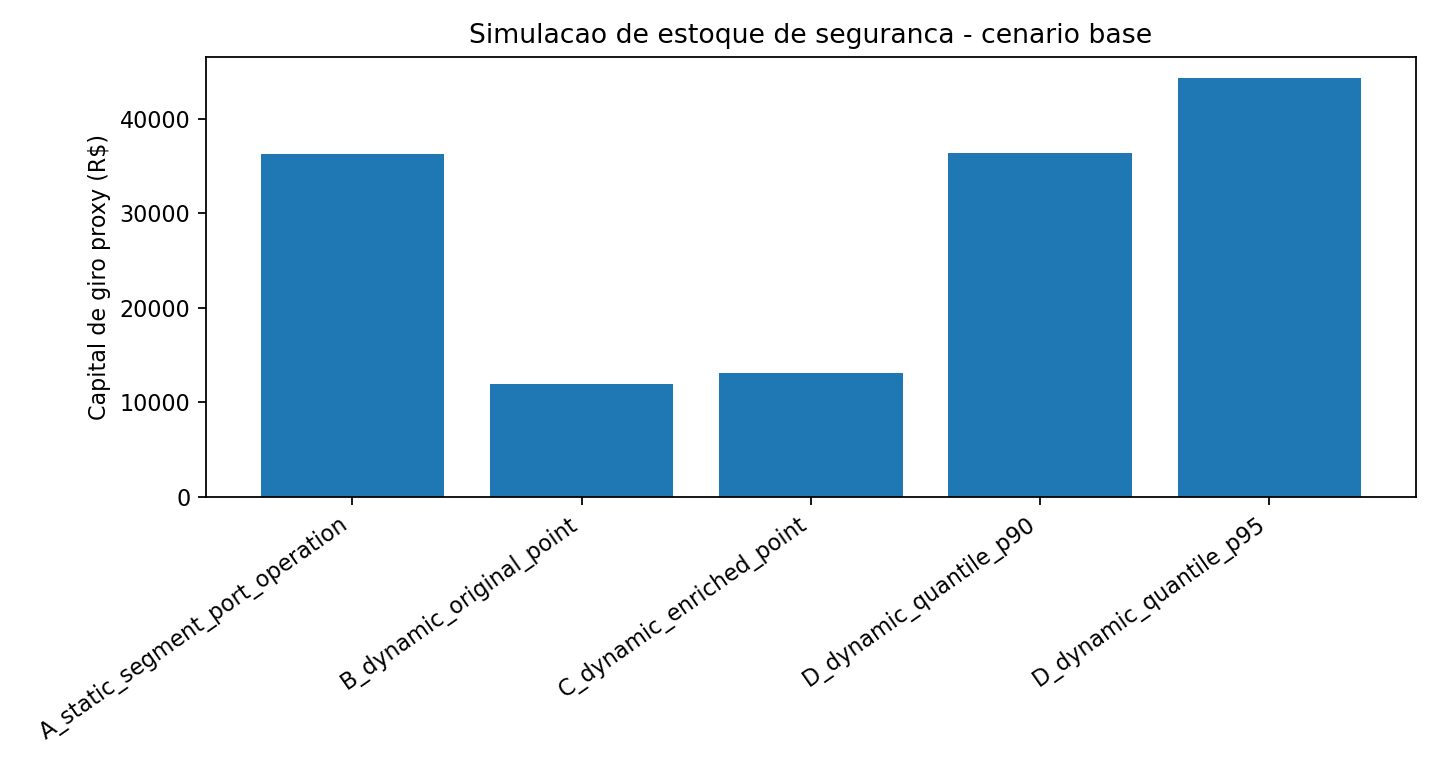

In [34]:
show_figure("safety_stock_working_capital.png")

A simulação mostra o trade-off entre proteção e capital de giro proxy. Políticas pontuais tendem a usar buffers menores, mas protegem menos contra a cauda. Políticas quantílicas elevam o buffer e aumentam a proteção, com custo maior em estoque de segurança.

# 12. Conclusão do notebook

O experimento final mostra que o uso de features históricas temporalmente seguras melhora a previsão de permanência portuária em relação ao conjunto original de variáveis. O modelo pontual selecionado foi o **HistGradientBoosting com `ENRICHED_SAFE_HISTORY`**, escolhido em validação antes de consultar o teste final.

As features históricas são importantes porque incorporam memória operacional conhecida no instante da chegada: fluxo recente, estado reconstruído do porto, desempenho anterior, histórico de embarcação, rota, origem/destino e mix operacional. Essa informação aproxima o problema da realidade operacional sem violar a regra de anti-leakage.

Os quantis P50, P90 e P95 complementam a previsão pontual ao representar risco e incerteza. Eles são especialmente úteis para a ponte com estoque de segurança, pois decisões de buffer dependem não apenas do lead time esperado, mas também da variabilidade e da cauda da distribuição.

Por fim, a simulação de estoque de segurança deve ser lida como análise de cenário. Ela conecta a previsão de permanência portuária a uma lógica de capital de giro, sem afirmar economia real observada, pois o dataset não contém demanda, estoque e custos reais de uma empresa específica.

In [35]:
official_checks = pd.DataFrame(
    {
        "checagem": [
            "artefatos oficiais encontrados",
            "testes de leakage aprovados",
            "modelo vencedor",
            "feature set vencedor",
            "final_test usado apenas após seleção",
        ],
        "resultado": [
            True,
            bool(leakage_tests["passed"].all()),
            winner["model"],
            winner["feature_config"],
            True,
        ],
    }
)
official_checks

,checagem,resultado
0,artefatos oficiais encontrados,True
1,testes de leakage aprovados,True
2,modelo vencedor,HistGradientBoosting
3,feature set vencedor,ENRICHED_SAFE_HISTORY
4,final_test usado apenas após seleção,True
